1.1 The operator (Hamiltonian)

In [3]:
from qiskit.quantum_info import SparsePauliOp
# Sparse N-qubit operator in a Pauli basis

hamiltonian = SparsePauliOp(
    [
        "IIII",
        "IIIZ",
        "IZII",
        "IIZI",
        "ZIII",
        "IZIZ",
        "IIZZ",
        "ZIIZ",
        "IZZI",
        "ZZII",
        "ZIZI",
        "YYYY",
        "XXYY",
        "YYXX",
        "XXXX",
    ],
    coeffs=[
        -0.09820182 + 0.0j,
        -0.1740751 + 0.0j,
        -0.1740751 + 0.0j,
        0.2242933 + 0.0j,
        0.2242933 + 0.0j,
        0.16891402 + 0.0j,
        0.1210099 + 0.0j,
        0.16631441 + 0.0j,
        0.16631441 + 0.0j,
        0.1210099 + 0.0j,
        0.17504456 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
        0.04530451 + 0.0j,
    ],
)
# Hamiltonian for a simple Hydrogen molecule; Jordan-Wigner mapper
# Constructing a Hamiltonian for four qubits by tensor products of the Pauli matrices, number of Pauli
# matrices determined by the number of qubits

# ???? Grouping, commutation
# A Hamiltonian generally cannot be estimated all at once. We split up the basis into multiple
# groups to be estimated separately and finallly combine the results.

In [4]:
import numpy as np

A = np.array(hamiltonian) # Make the H into an array
eigenvalues, eigenvectors = np.linalg.eigh(A)
# Use classical eigensolver to find the eigenvalues and eigenvectors of a Hermitian matrix
print("The ground state energy is ", min(eigenvalues), "hartrees")

The ground state energy is  -1.1459778447627311 hartrees


3. Example Hamiltonian

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [7]:
from qiskit.quantum_info import SparsePauliOp

hamiltonian = SparsePauliOp.from_list(
    [("YZ", 0.3980), ("ZI", -0.3980), ("ZZ", -0.0113), ("XX", 0.1810)]
) # Building the small hamiltonian from Pauli strings (N_{GCP} = 3)

A = np.array(hamiltonian) # making the Hamiltonian into an array
eigenvalues, eigenvectors = np.linalg.eigh(A)
print("The ground state energy is: ", min(eigenvalues))

The ground state energy is:  -0.7029303944595311


This circuit has 4 parameters


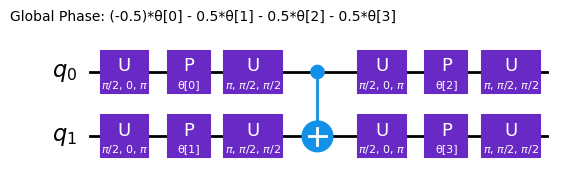

In [105]:
from qiskit.circuit.library import efficient_su2 # importing a prefabricated ansatz circuit and operator class

ansatz = efficient_su2(
    hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], entanglement="circular", reps=1

)

# input the number of qubits, gates to apply to each qubit, and entanglement structure. reps: number of repetition 
# after entanglement. SU(2): Special Unitary 2-D matrices

num_parameters = ansatz.num_parameters
print("This circuit has", num_parameters, "parameters")
ansatz.decompose().draw("mpl", style="textbook") # drawing with matplotlib in textbook style

In [9]:
# from qiskit_ibm_runtime import QiskitRuntimeService, Session
# from qiskit_ibm_runtime import EstimatorV2 as Estimator

# service = QiskitRuntimeService()
# backend = service.least_busy(operational=1, simulator=1)

# print(backend)

## No account yet.

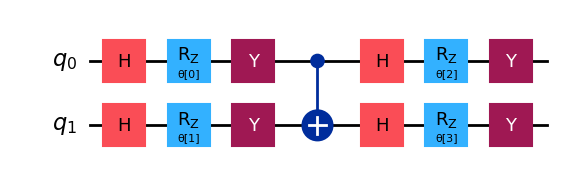

In [107]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# target = backend.target
pm = generate_preset_pass_manager(optimization_level=2)

ansatz_isa = pm.run(ansatz)

ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

# transpile the ansatz for our hardware and visualize

In [10]:
from qiskit.primitives import StatevectorEstimator as Estimator
# Local estimator
estimator = Estimator()

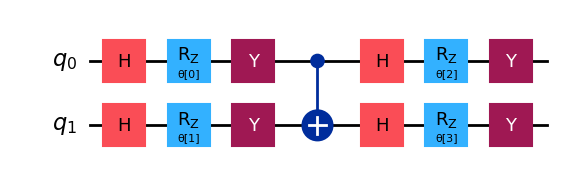

In [52]:
# Alternative method
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Create a local simulator backend
backend = AerSimulator() 

# Now target = backend.target will work locally
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

ansatz_isa = pm.run(ansatz)
ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [13]:
hamiltonian_isa = hamiltonian.apply_layout(layout=ansatz_isa.layout)
# Mapping the Hamiltonian to match the qubits

In [54]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        cost_history_dict: Dictionary for storing intermediate results

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]

    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(energy)
    print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")

    return energy

# Defining a function that returns the cost function associated with an ansatz and params.

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

# Tracking the history of cost functions for convergence analysis

In [56]:
x0 = 2 * np.pi * np.random.random(num_parameters)
# Choosing random initial parameters. np.random.random returns an array of random numbers between [0.0, 1.0)

In [58]:
res = minimize(
    cost_func,
    x0,
    args=(ansatz_isa, hamiltonian_isa, estimator),
    method="cobyla",
    options={"maxiter": 50},
)

Iters. done: 1 [Current cost: 0.33816610365048283]
Iters. done: 2 [Current cost: 0.37470174234374815]
Iters. done: 3 [Current cost: 0.39579939134503206]
Iters. done: 4 [Current cost: 0.30689501069601366]
Iters. done: 5 [Current cost: 0.4449788064826258]
Iters. done: 6 [Current cost: 0.02668980445138075]
Iters. done: 7 [Current cost: -0.45254047239971884]
Iters. done: 8 [Current cost: -0.5377909422582098]
Iters. done: 9 [Current cost: -0.3999385422837195]
Iters. done: 10 [Current cost: -0.4654031749627739]
Iters. done: 11 [Current cost: -0.4777451652409055]
Iters. done: 12 [Current cost: -0.42299018269642363]
Iters. done: 13 [Current cost: -0.46690842865371374]
Iters. done: 14 [Current cost: -0.5263775489396818]
Iters. done: 15 [Current cost: -0.5438435350758632]
Iters. done: 16 [Current cost: -0.5418457684947302]
Iters. done: 17 [Current cost: -0.5892892820555833]
Iters. done: 18 [Current cost: -0.6101225229937364]
Iters. done: 19 [Current cost: -0.5985824130165083]
Iters. done: 20 [Cu

In [62]:
# Alternative approach:

from qiskit_aer.primitives import EstimatorV2
from scipy.optimize import minimize

# 1. Initialize the Aer estimator locally
estimator2 = EstimatorV2()
# Set shots to match your original hardware code
estimator2.options.default_shots = 10000

# 2. Run the optimizer
res = minimize(
    cost_func,
    x0,
    args=(ansatz_isa, hamiltonian_isa, estimator2),
    method="cobyla",
    options={"maxiter": 50},
)

Iters. done: 51 [Current cost: 0.3381661036504829]
Iters. done: 52 [Current cost: 0.3747017423437482]
Iters. done: 53 [Current cost: 0.3957993913450324]
Iters. done: 54 [Current cost: 0.30689501069601366]
Iters. done: 55 [Current cost: 0.444978806482626]
Iters. done: 56 [Current cost: 0.026689804451379806]
Iters. done: 57 [Current cost: -0.45254047239971984]
Iters. done: 58 [Current cost: -0.5377909422582097]
Iters. done: 59 [Current cost: -0.3999385422837193]
Iters. done: 60 [Current cost: -0.4654031749627744]
Iters. done: 61 [Current cost: -0.4777451652409055]
Iters. done: 62 [Current cost: -0.42299018269642324]
Iters. done: 63 [Current cost: -0.46690842865371374]
Iters. done: 64 [Current cost: -0.5701955779718062]
Iters. done: 65 [Current cost: -0.5665800015499939]
Iters. done: 66 [Current cost: -0.5825216934588823]
Iters. done: 67 [Current cost: -0.6139745385195221]
Iters. done: 68 [Current cost: -0.6205751510987434]
Iters. done: 69 [Current cost: -0.6345862152259599]
Iters. done: 

In [42]:
cost_history_dict

{'prev_vector': array([4.67865816, 0.96668526, 3.14455953, 7.85286939]),
 'iters': 100,
 'cost_history': [-0.22425260290860963,
  -0.307585478996403,
  0.06244299593857858,
  -0.1742911149741656,
  -0.42543281568897684,
  -0.39940158667537223,
  -0.2683857517267812,
  -0.46694867381401023,
  -0.5688887796361749,
  -0.5415817372339611,
  -0.5478921925524096,
  -0.6271455724042736,
  -0.6136582175034335,
  -0.5784012875332896,
  -0.6366760115333021,
  -0.6554396214425269,
  -0.6681819707757917,
  -0.6690840361287137,
  -0.6798686021919036,
  -0.6840592834368661,
  -0.6941686434875582,
  -0.6866696212369257,
  -0.6820554533604563,
  -0.6954515966822862,
  -0.7017054666073228,
  -0.6993312563714338,
  -0.7001992700883584,
  -0.6995746726003171,
  -0.6993450906563018,
  -0.7004315209843334,
  -0.7001056212627281,
  -0.7023075554099484,
  -0.7025756440662556,
  -0.7027825645603304,
  -0.7026614020506833,
  -0.7027688088226546,
  -0.7024895384864133,
  -0.7027561165917706,
  -0.70277266893711

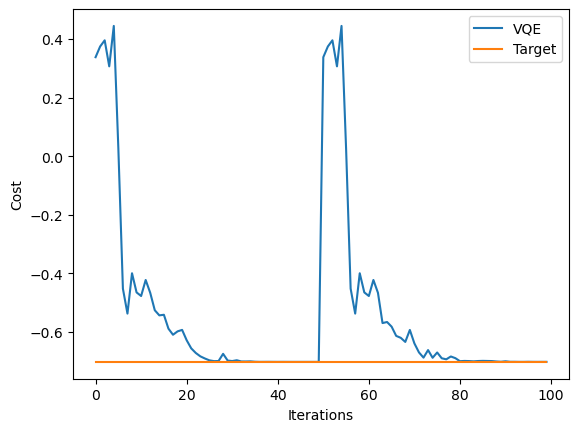

In [66]:
fig, ax = plt.subplots()
x = np.linspace(0, 10, 100)

# Define the constant function
constant = min(eigenvalues)
y_constant = np.full_like(x, constant)
ax.plot(
    range(cost_history_dict["iters"]), cost_history_dict["cost_history"], label="VQE"
)
ax.set_xlabel("Iterations")
ax.set_ylabel("Cost")
ax.plot(y_constant, label="Target")
plt.legend()
plt.draw()

# Convergence with two optimization schemes